In [1]:
import torch
from torch import nn
from dataset import Rice2
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam

from utility import plot_images, plot_samples, denorm, plot_losses
from losses import vae_loss
from models import Autoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
model = Autoencoder(latent_dim=512).to(device)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",        # wir wollen den Loss minimieren
    factor=0.5,        # lr wird halbiert wenn Plateau
    patience=2,        # ... nach 5 Epochen ohne Verbesserung
    threshold=0.1
)

num_epochs = 50
batch_size = 8
beta = 0.01
train_losses, val_losses = [], []
train_recon, val_recon = [], []
train_kl, val_kl = [], []

#data_dir = "/home/christopher/sync/projekte/GNN_projekt/RICE_DATASET/RICE2"
data_dir ="/data/home/lec42675/cloud_removal/RICE_DATASET/RICE2"

full_dataset = Rice2(data_dir, augment=False)
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
training_data, val_data = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Train-Subset auf augmentierte Version umbiegen
train_aug = Rice2(data_dir, augment=True)
training_data.dataset = train_aug   # Subset nutzt jetzt die augmentierte Quelle


train_dataloader = DataLoader(training_data, batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size, shuffle=True)

/data/home/lec42675/.venv/gpu-env/lib/python3.10/site-packages/torchvision/transforms/v2/functional/_deprecated.py:12: UserWarning: The function `to_tensor(...)` is deprecated and will be removed in a future release. Instead, please use `to_image(...)` followed by `to_dtype(..., dtype=torch.float32, scale=True)`.
  warnings.warn(


Epoch [1/50], Train: 0.3196, Val: 0.2773, LR: 1.00e-04


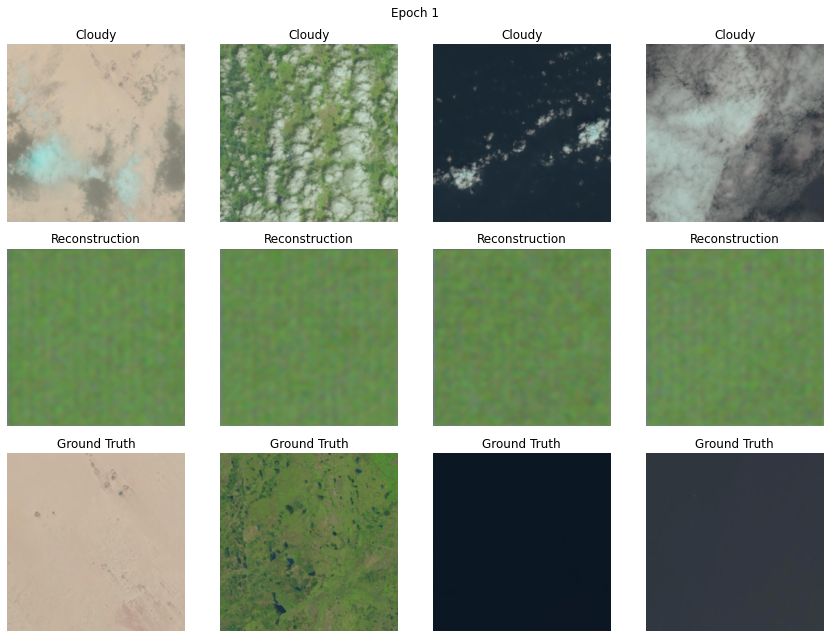

Epoch [2/50], Train: 0.2843, Val: 0.4179, LR: 1.00e-04
Epoch [3/50], Train: 0.2889, Val: 0.2436, LR: 1.00e-04
Epoch [4/50], Train: 0.2795, Val: 0.1754, LR: 1.00e-04
Epoch [5/50], Train: 0.2387, Val: 0.1935, LR: 1.00e-04
Epoch [6/50], Train: 0.2127, Val: 0.1581, LR: 1.00e-04


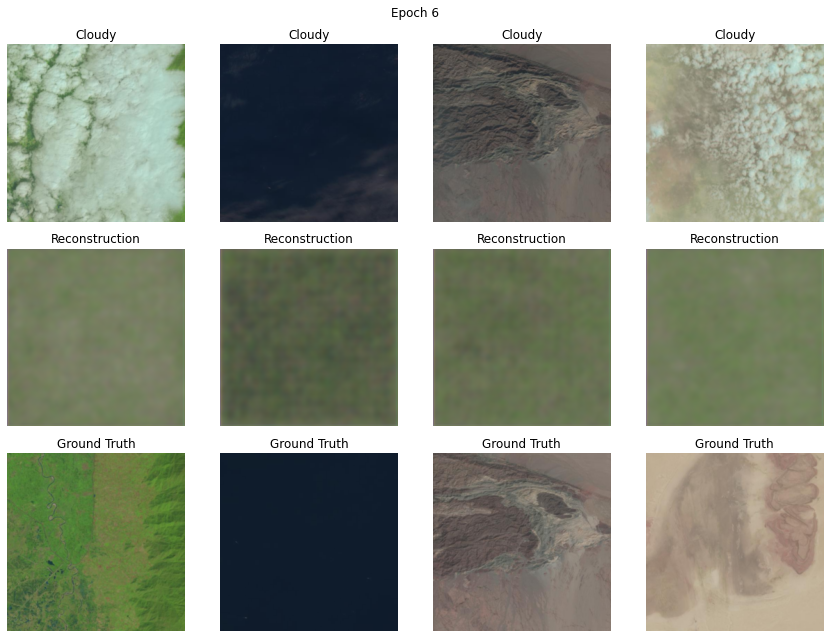

Epoch [7/50], Train: 0.2116, Val: 0.1422, LR: 1.00e-04
Epoch [8/50], Train: 0.1954, Val: 0.1623, LR: 1.00e-04
Epoch [9/50], Train: 0.1806, Val: 0.1546, LR: 1.00e-04
Epoch [10/50], Train: 0.1984, Val: 0.2098, LR: 5.00e-05
Epoch [11/50], Train: 0.1689, Val: 0.1166, LR: 5.00e-05


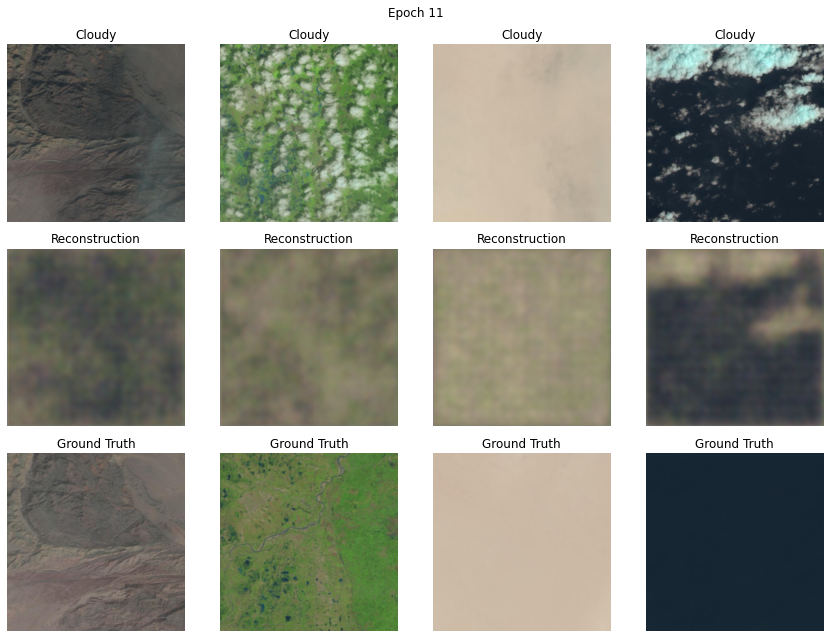

Epoch [12/50], Train: 0.1753, Val: 0.1465, LR: 5.00e-05
Epoch [13/50], Train: 0.1697, Val: 0.1038, LR: 5.00e-05
Epoch [14/50], Train: 0.1773, Val: 0.1322, LR: 5.00e-05
Epoch [15/50], Train: 0.1572, Val: 0.1184, LR: 5.00e-05
Epoch [16/50], Train: 0.1480, Val: 0.1252, LR: 2.50e-05


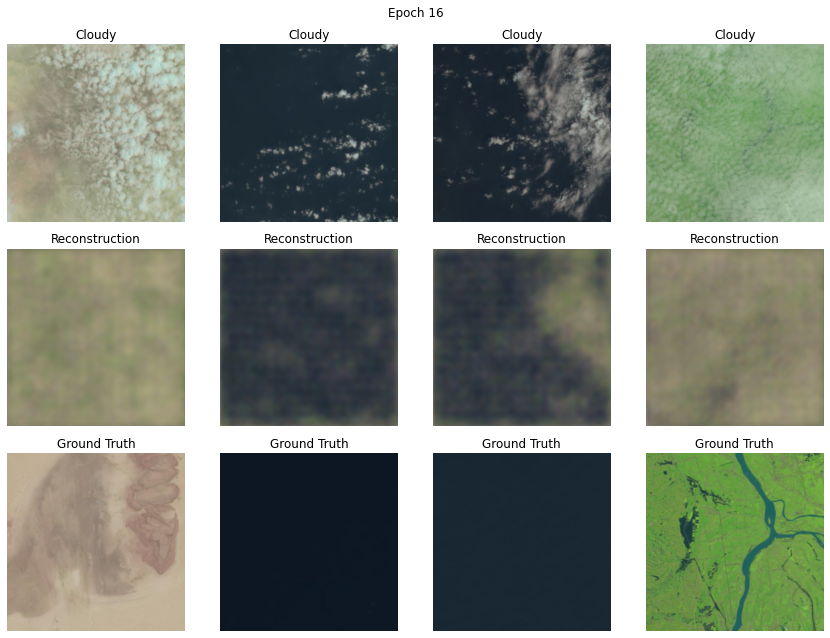

Epoch [17/50], Train: 0.1317, Val: 0.0866, LR: 2.50e-05
Epoch [18/50], Train: 0.1476, Val: 0.0967, LR: 2.50e-05
Epoch [19/50], Train: 0.1425, Val: 0.1287, LR: 2.50e-05
Epoch [20/50], Train: 0.1288, Val: 0.0870, LR: 1.25e-05
Epoch [21/50], Train: 0.1217, Val: 0.0945, LR: 1.25e-05


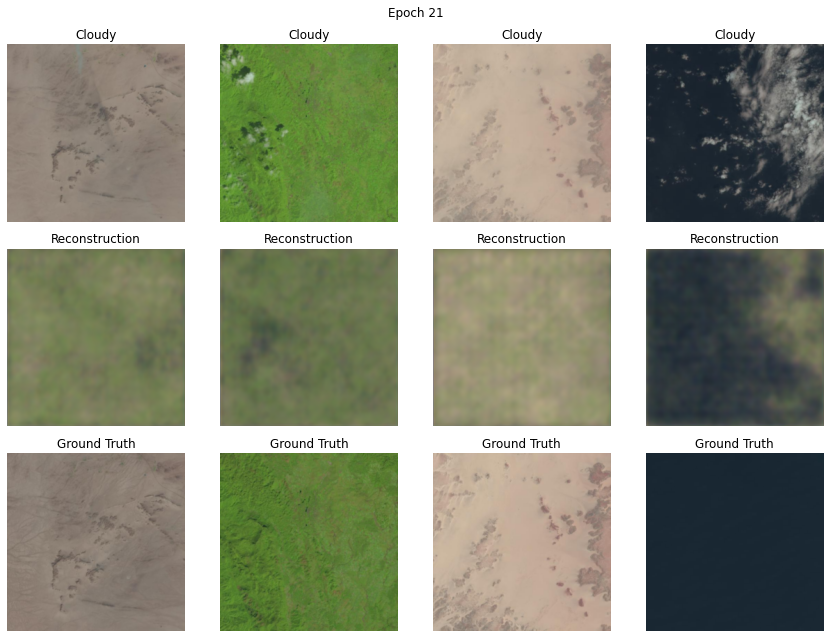

Epoch [22/50], Train: 0.1152, Val: 0.0865, LR: 1.25e-05
Epoch [23/50], Train: 0.1139, Val: 0.0995, LR: 6.25e-06
Epoch [24/50], Train: 0.1121, Val: 0.0950, LR: 6.25e-06
Epoch [25/50], Train: 0.1074, Val: 0.0849, LR: 6.25e-06
Epoch [26/50], Train: 0.1085, Val: 0.0887, LR: 3.13e-06


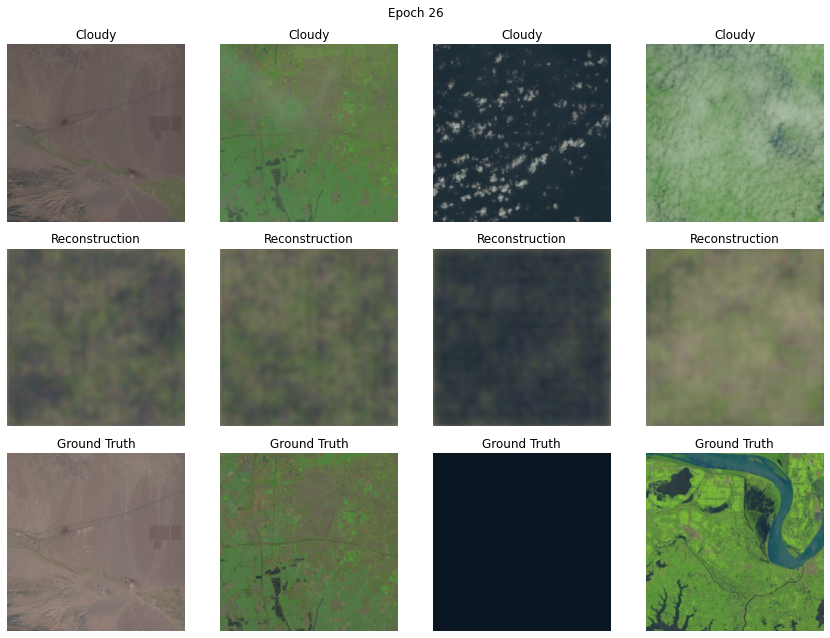

Epoch [27/50], Train: 0.1341, Val: 0.1430, LR: 3.13e-06
Epoch [28/50], Train: 0.1134, Val: 0.0851, LR: 3.13e-06
Epoch [29/50], Train: 0.1173, Val: 0.0827, LR: 1.56e-06
Epoch [30/50], Train: 0.1075, Val: 0.0881, LR: 1.56e-06
Epoch [31/50], Train: 0.1087, Val: 0.0824, LR: 1.56e-06


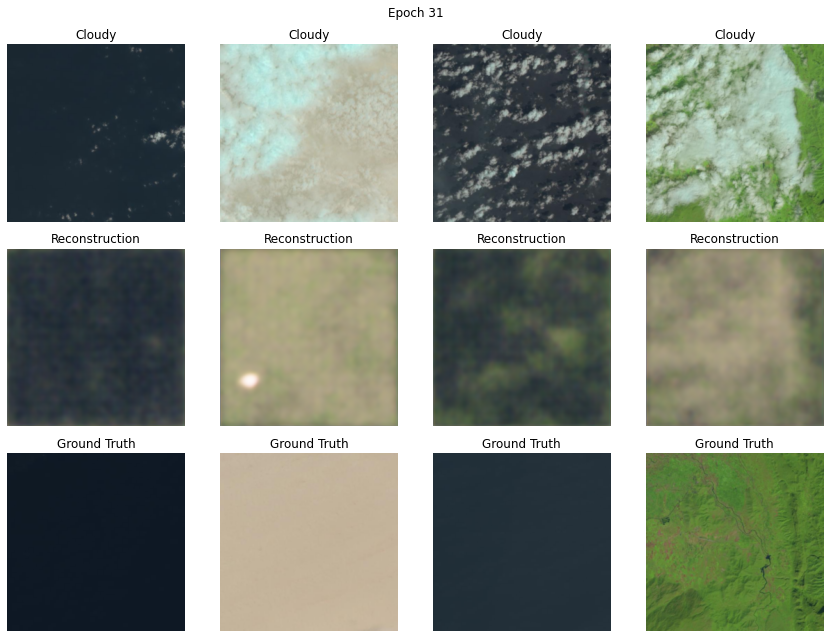

Epoch [32/50], Train: 0.1181, Val: 0.0886, LR: 7.81e-07
Epoch [33/50], Train: 0.1082, Val: 0.0864, LR: 7.81e-07
Epoch [34/50], Train: 0.1064, Val: 0.0899, LR: 7.81e-07
Epoch [35/50], Train: 0.1041, Val: 0.0868, LR: 3.91e-07
Epoch [36/50], Train: 0.1125, Val: 0.0921, LR: 3.91e-07


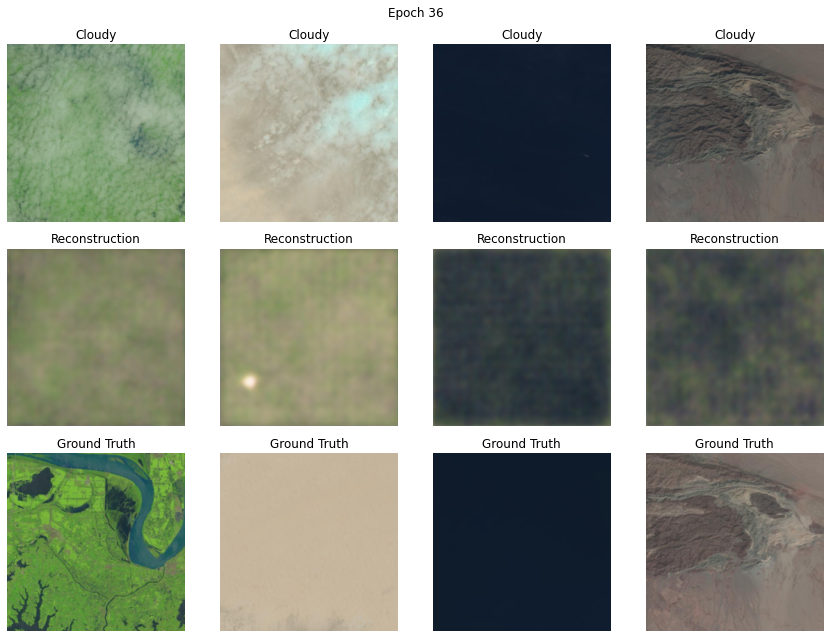

Epoch [37/50], Train: 0.1082, Val: 0.0842, LR: 3.91e-07
Epoch [38/50], Train: 0.1111, Val: 0.0975, LR: 1.95e-07
Epoch [39/50], Train: 0.1161, Val: 0.0943, LR: 1.95e-07
Epoch [40/50], Train: 0.1161, Val: 0.0823, LR: 1.95e-07
Epoch [41/50], Train: 0.1170, Val: 0.0868, LR: 9.77e-08


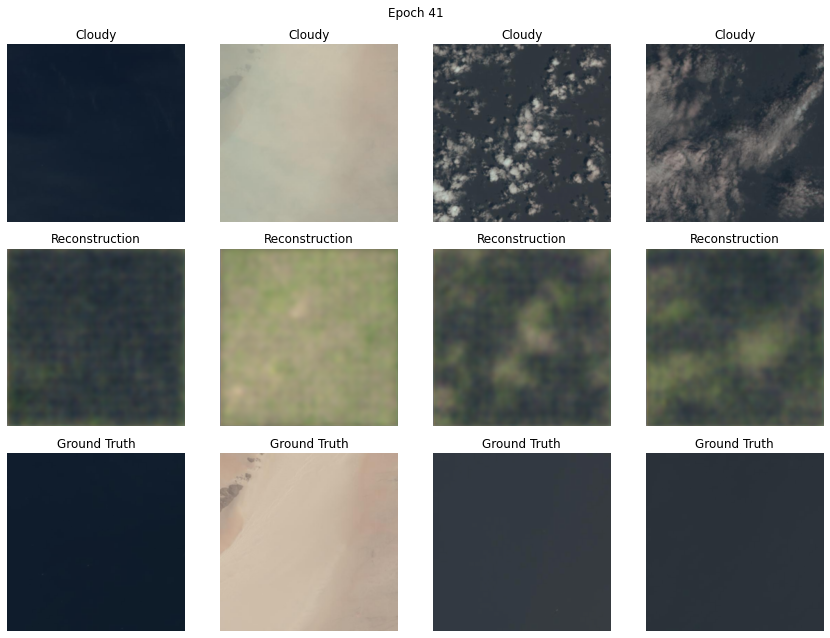

Epoch [42/50], Train: 0.1192, Val: 0.0831, LR: 9.77e-08
Epoch [43/50], Train: 0.1082, Val: 0.0829, LR: 9.77e-08
Epoch [44/50], Train: 0.1072, Val: 0.0856, LR: 4.88e-08
Epoch [45/50], Train: 0.1202, Val: 0.0903, LR: 4.88e-08
Epoch [46/50], Train: 0.1103, Val: 0.0809, LR: 4.88e-08


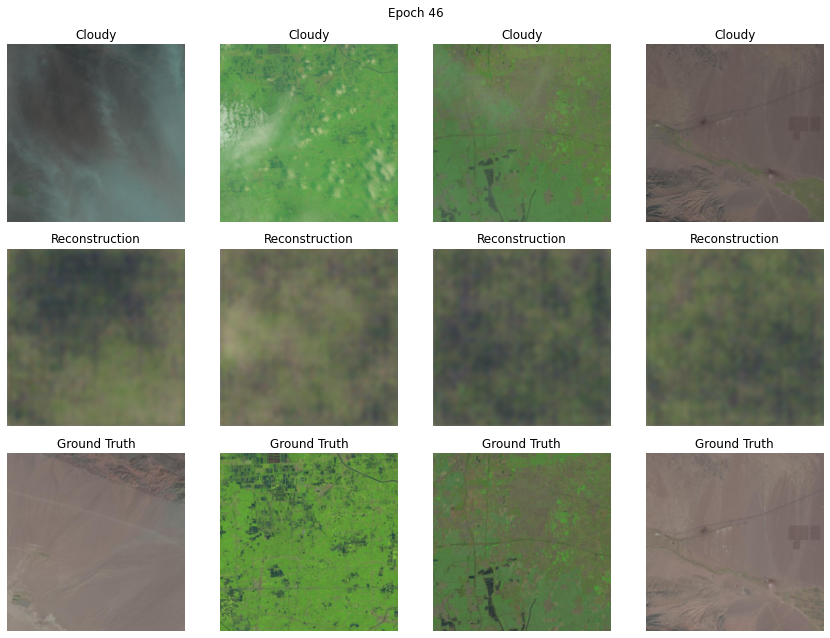

Epoch [47/50], Train: 0.1168, Val: 0.0990, LR: 2.44e-08
Epoch [48/50], Train: 0.1156, Val: 0.0790, LR: 2.44e-08
Epoch [49/50], Train: 0.1095, Val: 0.0866, LR: 2.44e-08
Epoch [50/50], Train: 0.1061, Val: 0.0833, LR: 1.22e-08


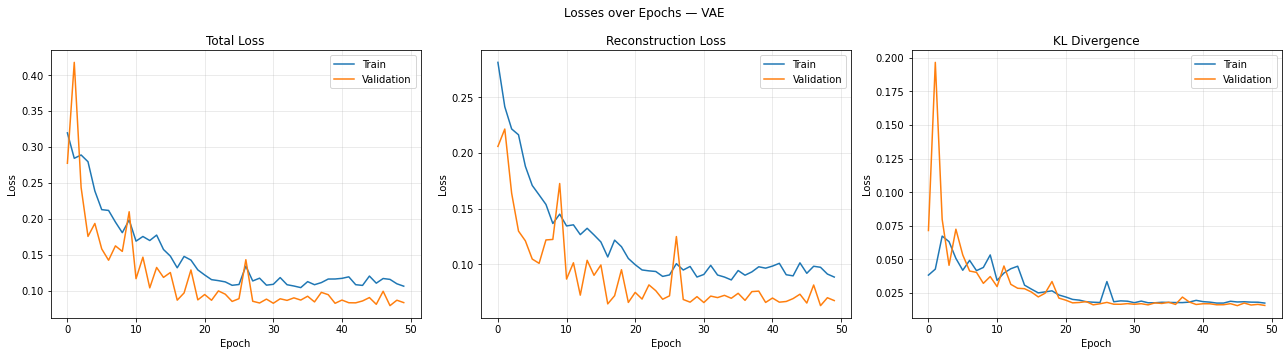

In [3]:
for epoch in range(num_epochs):
    model.train()
    total_loss = total_recon = total_kl = 0
    for cloudy, label, mask in train_dataloader:
        cloudy, label = cloudy.to(device), label.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(cloudy, label)
        loss, recon_loss, kl_loss = vae_loss(recon, label, mu, logvar, beta)
        loss.backward()
        optimizer.step()
        total_loss  += loss.item()
        total_recon += recon_loss.item()
        total_kl    += kl_loss.item()
    train_losses.append(total_loss / len(train_dataloader))
    train_recon.append(total_recon / len(train_dataloader))
    train_kl.append(total_kl / len(train_dataloader))

    model.eval()
    total_loss = total_recon = total_kl = 0
    with torch.no_grad():
        for cloudy, label, mask in val_dataloader:
            cloudy, label = cloudy.to(device), label.to(device)
            recon, mu, logvar = model(cloudy, label)
            loss, recon_loss, kl_loss = vae_loss(recon, label, mu, logvar, beta)
            total_loss  += loss.item()
            total_recon += recon_loss.item()
            total_kl    += kl_loss.item()
    val_losses.append(total_loss / len(val_dataloader))
    val_recon.append(total_recon / len(val_dataloader))
    val_kl.append(total_kl / len(val_dataloader))

    scheduler.step(val_losses[-1])
    
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch [{epoch+1}/{num_epochs}], Train: {train_losses[-1]:.4f}, "
          f"Val: {val_losses[-1]:.4f}, LR: {current_lr:.2e}")
    if epoch % 5 == 0:
        plot_samples(model, val_dataloader, device, epoch)
    
plot_losses(train_losses, val_losses, train_recon, val_recon, train_kl, val_kl, model_name="VAE")

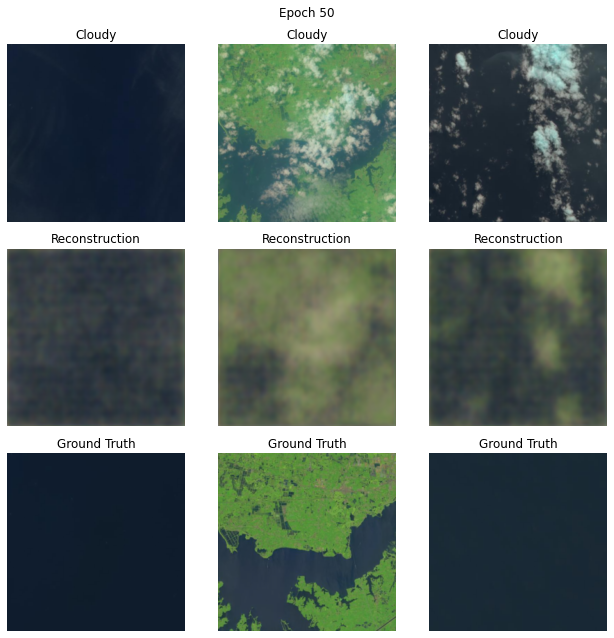

In [7]:
import matplotlib.pyplot as plt
n=3
model.eval()
cloudy, label, mask = next(iter(train_dataloader))
cloudy, label = cloudy.to(device), label.to(device)

with torch.no_grad():
    recon = model.generate(cloudy)  # Testzeit: z aus N(0,1)

cloudy = denorm(cloudy.cpu())
label = denorm(label.cpu())
recon = denorm(recon.cpu())

fig, axes = plt.subplots(3, n, figsize=(n * 3, 9))
for i in range(n):
    axes[0, i].imshow(cloudy[i].permute(1, 2, 0))
    axes[0, i].set_title("Cloudy")
    axes[1, i].imshow(recon[i].permute(1, 2, 0))
    axes[1, i].set_title("Reconstruction")
    axes[2, i].imshow(label[i].permute(1, 2, 0))
    axes[2, i].set_title("Ground Truth")
    for row in range(3):
        axes[row, i].axis("off")
fig.suptitle(f"Epoch {epoch+1}")
plt.tight_layout()
plt.show()
